# Model Training & Backtest — Corn/Soybean Spread Strategy

Trains an XGBoost classifier on the **selected features** from feature selection.

Uses a **time-based train/test split** to simulate real deployment:
- Train on first 75% of data
- Test on final 25% (out-of-sample)

Only trades when model confidence exceeds a threshold.

## Step 1 — Load Data & Selected Features

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# ── Load feature matrix ───────────────────────────────────────────────────────
df = pd.read_csv(
    r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\feature_matrix.csv",
    index_col='date',
    parse_dates=True
)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Shape: (5303, 169)
Date range: 2005-01-05 to 2026-02-02


In [4]:
# ── Load selected features ────────────────────────────────────────────────────
selected_features = pd.read_csv(
    r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\selected_features.csv"
)['selected_features'].tolist()

print(f"Selected features ({len(selected_features)} total):")
for f in selected_features:
    print(f"  {f}")

Selected features (11 total):
  soil_temperature_28_to_100cm_mean_loc1.0
  soil_temperature_28_to_100cm_mean_loc2.0
  soil_moisture_28_to_100cm_mean_loc2.0
  soil_temperature_0_to_100cm_mean_loc1.0
  soil_moisture_7_to_28cm_mean_loc2.0
  soil_moisture_28_to_100cm_mean_loc3.0
  ecm_spread
  soil_moisture_0_to_100cm_mean_loc2.0
  soil_temperature_28_to_100cm_mean_loc3.0
  soil_temperature_0_to_100cm_mean_loc2.0
  soil_moisture_7_to_28cm_mean_loc3.0


In [5]:
# ── Build X and y ─────────────────────────────────────────────────────────────
X = df[selected_features].copy()
y_raw = df['bin'].copy()
ret = df['ret'].copy()  # actual spread return — needed for PnL calculation

# Impute any NaNs (same logic as feature selection)
roll_cols = [c for c in X.columns if any(k in c for k in ['z_score', 'lag', 'spread'])]
if roll_cols:
    X[roll_cols] = X[roll_cols].ffill().bfill()

for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

# Drop rows with NaN labels
valid = y_raw.notna()
X = X[valid]
y_raw = y_raw[valid]
ret = ret[valid]

# Remap labels: -1 → 0 (SL), 0 → 1 (timeout), 1 → 2 (PT)
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
y = y_raw.map(label_map).astype(int)

print(f"\nFinal dataset:")
print(f"X shape: {X.shape}")
print(f"Label distribution:")
print(y.value_counts().sort_index())
print("  0 = Stop Loss  |  1 = Time-out  |  2 = Profit Take")
print(f"\nNaNs in X: {X.isna().sum().sum()}")


Final dataset:
X shape: (5303, 11)
Label distribution:
bin
0    2771
1      10
2    2522
Name: count, dtype: int64
  0 = Stop Loss  |  1 = Time-out  |  2 = Profit Take

NaNs in X: 0


## Step 2 — Train/Test Split (Time-Based)

Train on first 75%, test on final 25% to simulate real deployment.

In [6]:
split_idx = int(0.75 * len(X))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
ret_test = ret.iloc[split_idx:]  # only need returns for test period

print(f"Train: {X_train.shape[0]} samples | {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test:  {X_test.shape[0]} samples | {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"\nTrain label distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest label distribution:")
print(y_test.value_counts().sort_index())

Train: 3977 samples | 2005-01-05 to 2020-10-21
Test:  1326 samples | 2020-10-22 to 2026-02-02

Train label distribution:
bin
0    2108
1       2
2    1867
Name: count, dtype: int64

Test label distribution:
bin
0    663
1      8
2    655
Name: count, dtype: int64


## Step 3 — Train XGBoost Classifier

In [7]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

print("Training model...")
model.fit(X_train, y_train)
print("Done.\n")

# ── Training accuracy ─────────────────────────────────────────────────────────
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc:.3f}")

# ── Test accuracy ─────────────────────────────────────────────────────────────
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Random baseline (largest class): {y_test.value_counts().max() / len(y_test):.3f}")

Training model...
Done.

Training accuracy: 0.869
Test accuracy: 0.551
Random baseline (largest class): 0.500


In [8]:
# ── Detailed classification report ────────────────────────────────────────────
print("\nClassification Report (Test Set):")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Stop Loss (0)', 'Time-out (1)', 'Profit Take (2)']
))


Classification Report (Test Set):
                 precision    recall  f1-score   support

  Stop Loss (0)       0.55      0.59      0.57       663
   Time-out (1)       0.00      0.00      0.00         8
Profit Take (2)       0.55      0.52      0.54       655

       accuracy                           0.55      1326
      macro avg       0.37      0.37      0.37      1326
   weighted avg       0.55      0.55      0.55      1326



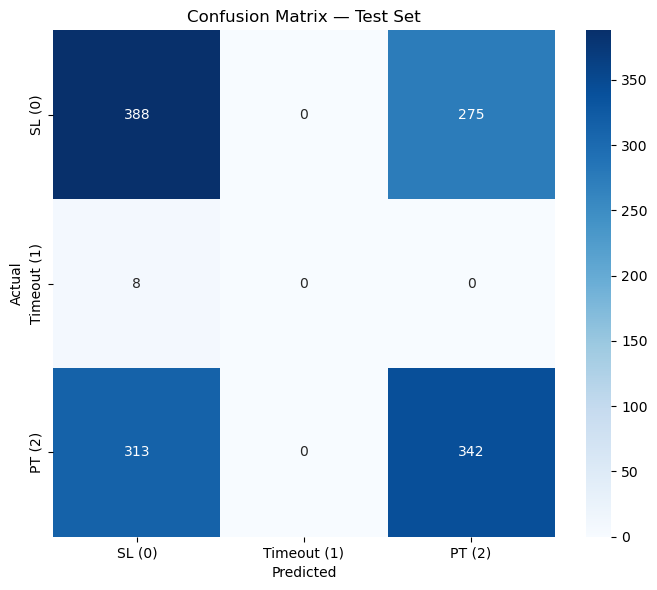

In [9]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['SL (0)', 'Timeout (1)', 'PT (2)'],
    yticklabels=['SL (0)', 'Timeout (1)', 'PT (2)'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## Step 4 — Predicted Probabilities & Confidence Analysis

In [10]:
# ── Get predicted probabilities ───────────────────────────────────────────────
# Shape: (n_samples, 3) — one column per class [P(SL), P(timeout), P(PT)]
proba = model.predict_proba(X_test)

results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'prob_SL': proba[:, 0],
    'prob_timeout': proba[:, 1],
    'prob_PT': proba[:, 2],
    'max_prob': proba.max(axis=1),          # model's confidence
    'predicted_class': proba.argmax(axis=1), # same as y_test_pred but derived from proba
    'ret': ret_test.values                   # actual spread return
}, index=X_test.index)

results['correct'] = (results['actual'] == results['predicted']).astype(int)

print("Sample predictions:")
print(results.head(10).to_string(float_format=lambda x: f"{x:.3f}"))

Sample predictions:
            actual  predicted  prob_SL  prob_timeout  prob_PT  max_prob  predicted_class    ret  correct
date                                                                                                    
2020-10-22       0          0    0.611         0.001    0.388     0.611                0 -0.019        1
2020-10-23       0          0    0.606         0.001    0.393     0.606                0 -0.016        1
2020-10-26       0          0    0.619         0.001    0.379     0.619                0 -0.016        1
2020-10-27       0          0    0.661         0.001    0.339     0.661                0 -0.012        1
2020-10-28       0          0    0.665         0.000    0.335     0.665                0 -0.013        1
2020-10-29       0          0    0.668         0.000    0.332     0.668                0 -0.024        1
2020-10-30       0          0    0.676         0.000    0.324     0.676                0 -0.019        1
2020-11-02       0          0    0.

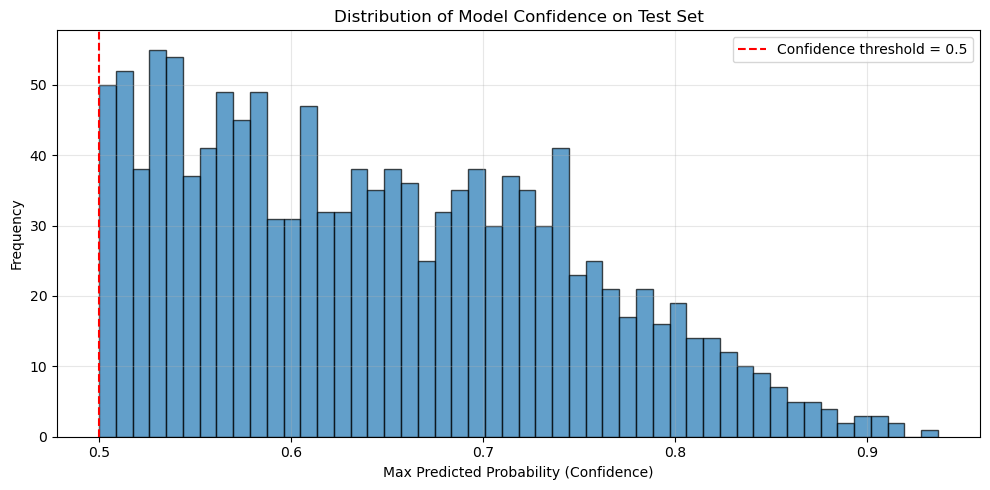


Mean confidence: 0.646
Median confidence: 0.635
% of predictions with confidence > 0.5: 99.9%


In [11]:
# ── Confidence distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(results['max_prob'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Confidence threshold = 0.5')
ax.set_xlabel('Max Predicted Probability (Confidence)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Model Confidence on Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMean confidence: {results['max_prob'].mean():.3f}")
print(f"Median confidence: {results['max_prob'].median():.3f}")
print(f"% of predictions with confidence > 0.5: {(results['max_prob'] > 0.5).mean() * 100:.1f}%")

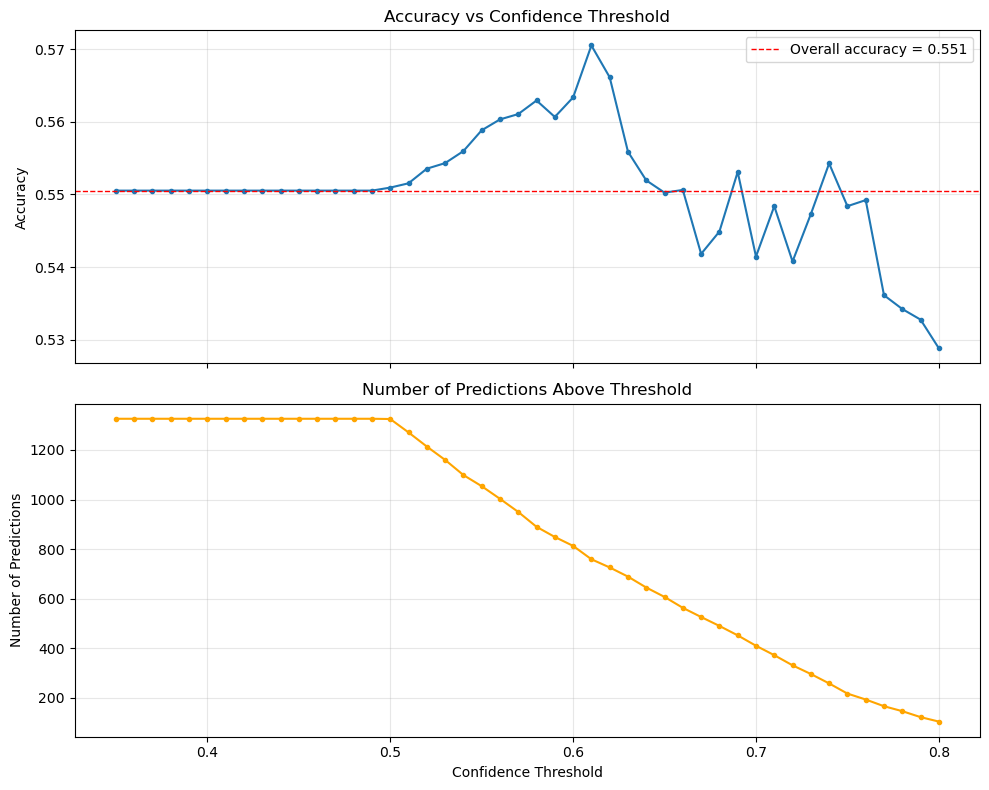

In [12]:
# ── Accuracy vs confidence threshold ──────────────────────────────────────────
thresholds = np.arange(0.35, 0.80, 0.01)
accs = []
counts = []

for thresh in thresholds:
    filtered = results[results['max_prob'] >= thresh]
    if len(filtered) > 0:
        acc = filtered['correct'].mean()
    else:
        acc = np.nan
    accs.append(acc)
    counts.append(len(filtered))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top: accuracy
ax1.plot(thresholds, accs, marker='o', markersize=3, linewidth=1.5)
ax1.axhline(test_acc, color='red', linestyle='--', linewidth=1, label=f'Overall accuracy = {test_acc:.3f}')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Confidence Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: sample count
ax2.plot(thresholds, counts, marker='o', markersize=3, linewidth=1.5, color='orange')
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Number of Predictions')
ax2.set_title('Number of Predictions Above Threshold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5 — Backtest with Confidence Threshold

Trading rules:
1. Only trade when `max_prob >= THRESHOLD` (default 0.5)
2. If `P(PT)` is highest → go **long** the spread (expect it to rise)
3. If `P(SL)` is highest → go **short** the spread (expect it to fall)
4. If `P(timeout)` is highest → **skip** (no edge)

Position sizing: constant 1 unit per trade.

In [13]:
CONFIDENCE_THRESHOLD = 0.50  # adjust based on accuracy vs threshold plot above

# ── Generate trading signals ──────────────────────────────────────────────────
bt = results.copy()

# Trade only if confidence exceeds threshold AND we're not predicting timeout
bt['trade'] = (
    (bt['max_prob'] >= CONFIDENCE_THRESHOLD) &
    (bt['predicted_class'] != 1)  # skip if predicting timeout
).astype(int)

# Position: +1 if predicting PT (class 2), -1 if predicting SL (class 0)
bt['position'] = np.where(
    bt['trade'] == 1,
    np.where(bt['predicted_class'] == 2, 1, -1),
    0
)

# PnL = position × actual spread return
bt['pnl'] = bt['position'] * bt['ret']

print(f"Backtest with confidence threshold = {CONFIDENCE_THRESHOLD:.2f}")
print(f"Total test observations: {len(bt)}")
print(f"Trades executed: {bt['trade'].sum()}")
print(f"  Long positions (predict PT): {(bt['position'] == 1).sum()}")
print(f"  Short positions (predict SL): {(bt['position'] == -1).sum()}")
print(f"  No trade: {(bt['position'] == 0).sum()}")

Backtest with confidence threshold = 0.50
Total test observations: 1326
Trades executed: 1325
  Long positions (predict PT): 616
  Short positions (predict SL): 709
  No trade: 1


In [14]:
# ── Performance metrics ───────────────────────────────────────────────────────
total_pnl = bt['pnl'].sum()
mean_pnl = bt['pnl'].mean()
std_pnl = bt['pnl'].std()
sharpe = (mean_pnl / std_pnl) * np.sqrt(252) if std_pnl > 0 else 0

trades_only = bt[bt['trade'] == 1]
if len(trades_only) > 0:
    win_rate = (trades_only['pnl'] > 0).mean()
    avg_win = trades_only[trades_only['pnl'] > 0]['pnl'].mean() if (trades_only['pnl'] > 0).any() else 0
    avg_loss = trades_only[trades_only['pnl'] < 0]['pnl'].mean() if (trades_only['pnl'] < 0).any() else 0
else:
    win_rate = avg_win = avg_loss = 0

print("\n=== Backtest Results ===")
print(f"Total PnL (spread units): {total_pnl:.4f}")
print(f"Mean daily PnL: {mean_pnl:.6f}")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"\nWin rate: {win_rate * 100:.1f}%")
print(f"Avg win: {avg_win:.4f}")
print(f"Avg loss: {avg_loss:.4f}")
if avg_loss != 0:
    print(f"Win/Loss ratio: {abs(avg_win / avg_loss):.2f}")


=== Backtest Results ===
Total PnL (spread units): 4.1518
Mean daily PnL: 0.003131
Annualized Sharpe Ratio: 1.75

Win rate: 55.3%
Avg win: 0.0253
Avg loss: -0.0243
Win/Loss ratio: 1.04


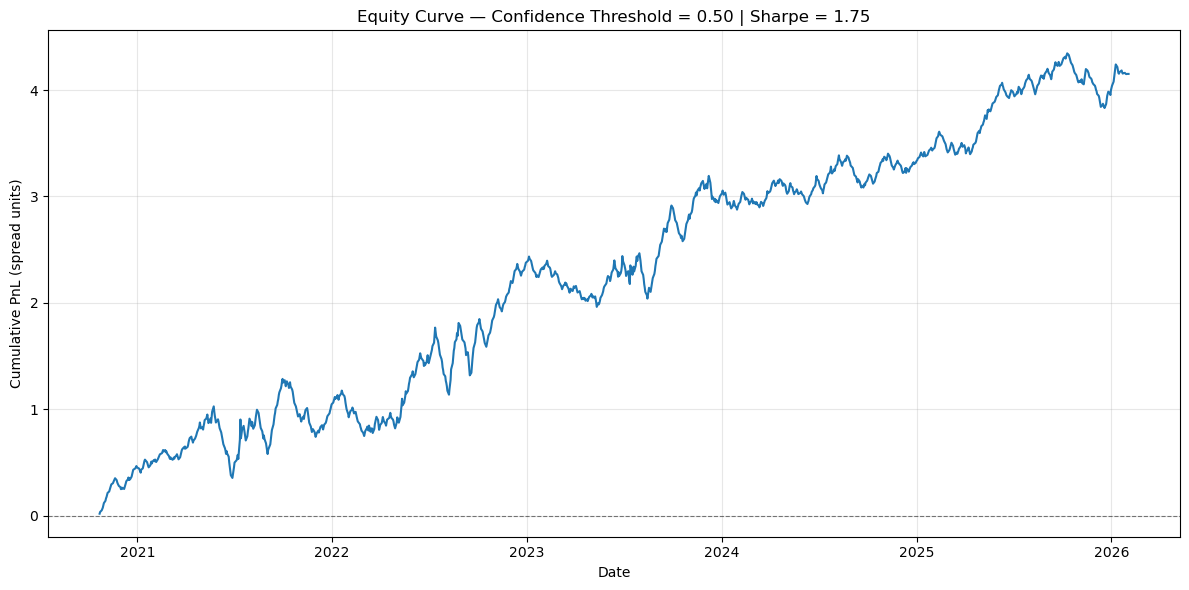

In [15]:
# ── Equity curve ──────────────────────────────────────────────────────────────
bt['cumulative_pnl'] = bt['pnl'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bt.index, bt['cumulative_pnl'], linewidth=1.5)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL (spread units)')
ax.set_title(f'Equity Curve — Confidence Threshold = {CONFIDENCE_THRESHOLD:.2f} | Sharpe = {sharpe:.2f}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Max drawdown: -0.6726 (on 2021-06-28)


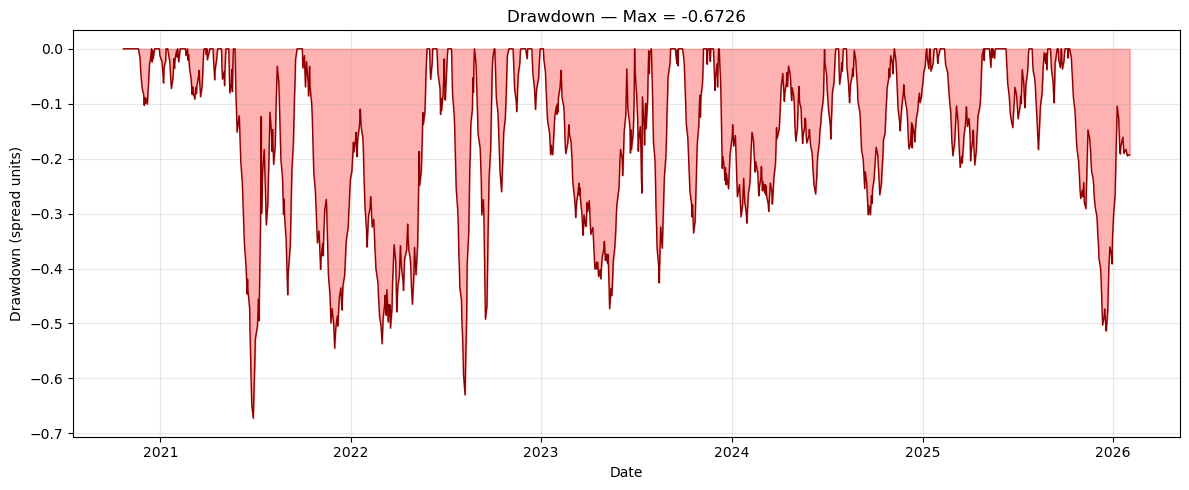

In [16]:
# ── Drawdown analysis ─────────────────────────────────────────────────────────
bt['running_max'] = bt['cumulative_pnl'].cummax()
bt['drawdown'] = bt['cumulative_pnl'] - bt['running_max']

max_dd = bt['drawdown'].min()
max_dd_date = bt['drawdown'].idxmin()

print(f"\nMax drawdown: {max_dd:.4f} (on {max_dd_date.date()})")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(bt.index, bt['drawdown'], 0, alpha=0.3, color='red')
ax.plot(bt.index, bt['drawdown'], linewidth=1, color='darkred')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (spread units)')
ax.set_title(f'Drawdown — Max = {max_dd:.4f}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Error Analysis

Where does the model go wrong?

In [17]:
# ── Confident but wrong predictions ───────────────────────────────────────────
confident = bt[bt['max_prob'] >= CONFIDENCE_THRESHOLD].copy()
errors = confident[confident['correct'] == 0]

print(f"Confident predictions (>= {CONFIDENCE_THRESHOLD:.2f}): {len(confident)}")
print(f"Errors among confident predictions: {len(errors)}")
print(f"Error rate on confident predictions: {len(errors) / len(confident) * 100:.1f}%\n")

if len(errors) > 0:
    print("Confusion on confident predictions:")
    print(pd.crosstab(
        errors['actual'],
        errors['predicted'],
        rownames=['Actual'],
        colnames=['Predicted'],
        margins=True
    ))
    print("\nSample of confident errors:")
    print(errors[['actual', 'predicted', 'max_prob', 'ret']].head(10).to_string(float_format=lambda x: f"{x:.3f}"))

Confident predictions (>= 0.50): 1325
Errors among confident predictions: 595
Error rate on confident predictions: 44.9%

Confusion on confident predictions:
Predicted    0    2  All
Actual                  
0            0  274  274
1            8    0    8
2          313    0  313
All        321  274  595

Sample of confident errors:
            actual  predicted  max_prob    ret
date                                          
2020-11-23       2          0     0.650  0.018
2020-11-24       2          0     0.660  0.019
2020-11-25       2          0     0.656  0.014
2020-11-27       2          0     0.649  0.020
2020-11-30       2          0     0.616  0.013
2020-12-01       2          0     0.579  0.019
2020-12-03       2          0     0.529  0.011
2020-12-07       0          2     0.521 -0.011
2020-12-16       0          2     0.511 -0.024
2020-12-18       0          2     0.561 -0.015


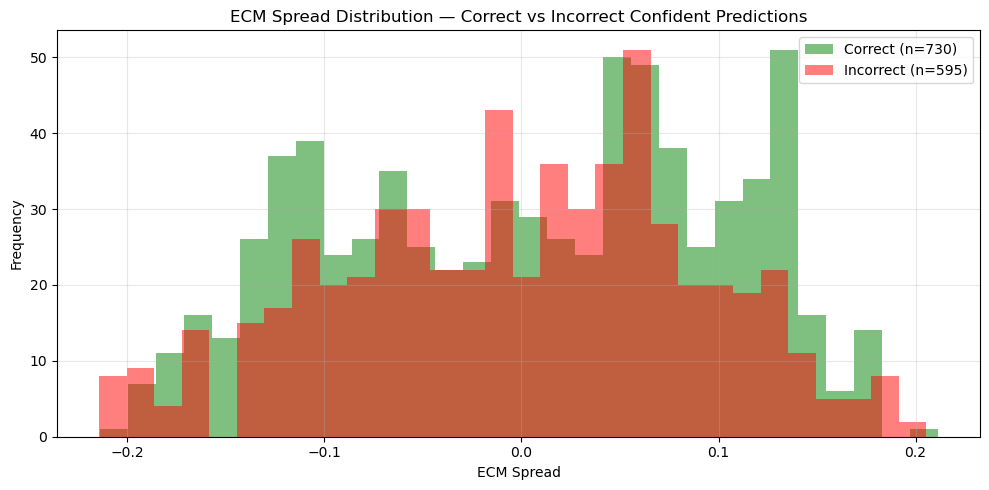

In [18]:
# ── Feature distributions: correct vs incorrect ───────────────────────────────
# Compare ecm_spread distribution for correct vs incorrect confident predictions
if 'ecm_spread' in selected_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    correct_conf = confident[confident['correct'] == 1]
    incorrect_conf = confident[confident['correct'] == 0]
    
    ax.hist(
        X_test.loc[correct_conf.index, 'ecm_spread'],
        bins=30,
        alpha=0.5,
        label=f'Correct (n={len(correct_conf)})',
        color='green'
    )
    ax.hist(
        X_test.loc[incorrect_conf.index, 'ecm_spread'],
        bins=30,
        alpha=0.5,
        label=f'Incorrect (n={len(incorrect_conf)})',
        color='red'
    )
    ax.set_xlabel('ECM Spread')
    ax.set_ylabel('Frequency')
    ax.set_title('ECM Spread Distribution — Correct vs Incorrect Confident Predictions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ecm_spread not in selected features — skipping distribution plot")

## Step 7 — Try Different Confidence Thresholds

Compare Sharpe ratios across different thresholds to find the optimal balance between trade frequency and accuracy.

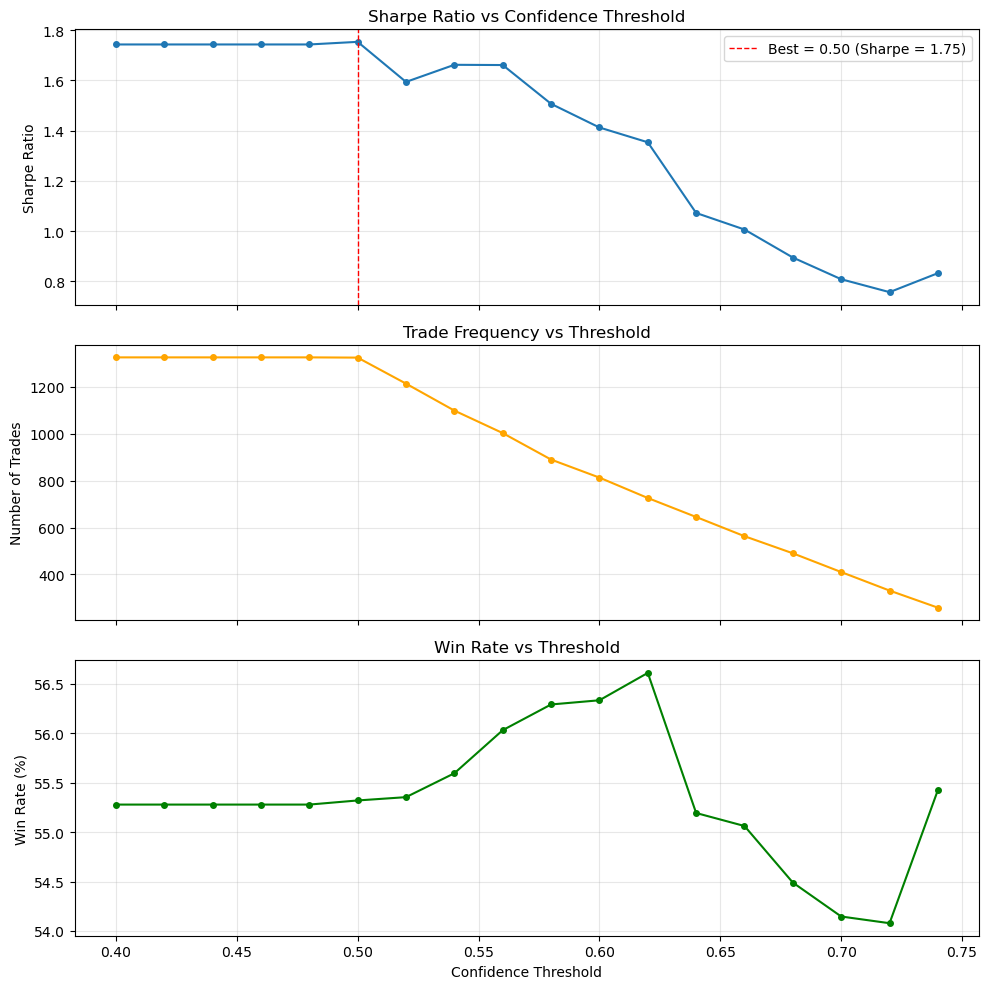


Optimal threshold: 0.50
Best Sharpe: 1.75
Trades at optimal: 1325
Win rate at optimal: 55.3%


In [19]:
# ── Scan across thresholds ────────────────────────────────────────────────────
thresholds = np.arange(0.40, 0.75, 0.02)
sharpes = []
n_trades = []
win_rates = []

for thresh in thresholds:
    bt_temp = results.copy()
    
    bt_temp['trade'] = (
        (bt_temp['max_prob'] >= thresh) &
        (bt_temp['predicted_class'] != 1)
    ).astype(int)
    
    bt_temp['position'] = np.where(
        bt_temp['trade'] == 1,
        np.where(bt_temp['predicted_class'] == 2, 1, -1),
        0
    )
    
    bt_temp['pnl'] = bt_temp['position'] * bt_temp['ret']
    
    mean_pnl = bt_temp['pnl'].mean()
    std_pnl = bt_temp['pnl'].std()
    sharpe_temp = (mean_pnl / std_pnl) * np.sqrt(252) if std_pnl > 0 else 0
    
    sharpes.append(sharpe_temp)
    n_trades.append(bt_temp['trade'].sum())
    
    trades_only = bt_temp[bt_temp['trade'] == 1]
    wr = (trades_only['pnl'] > 0).mean() if len(trades_only) > 0 else 0
    win_rates.append(wr)

# ── Plot results ──────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Sharpe
ax1.plot(thresholds, sharpes, marker='o', markersize=4, linewidth=1.5)
best_idx = np.argmax(sharpes)
ax1.axvline(thresholds[best_idx], color='red', linestyle='--', linewidth=1,
            label=f'Best = {thresholds[best_idx]:.2f} (Sharpe = {sharpes[best_idx]:.2f})')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio vs Confidence Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Number of trades
ax2.plot(thresholds, n_trades, marker='o', markersize=4, linewidth=1.5, color='orange')
ax2.set_ylabel('Number of Trades')
ax2.set_title('Trade Frequency vs Threshold')
ax2.grid(True, alpha=0.3)

# Win rate
ax3.plot(thresholds, [w * 100 for w in win_rates], marker='o', markersize=4, linewidth=1.5, color='green')
ax3.set_xlabel('Confidence Threshold')
ax3.set_ylabel('Win Rate (%)')
ax3.set_title('Win Rate vs Threshold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimal threshold: {thresholds[best_idx]:.2f}")
print(f"Best Sharpe: {sharpes[best_idx]:.2f}")
print(f"Trades at optimal: {n_trades[best_idx]}")
print(f"Win rate at optimal: {win_rates[best_idx] * 100:.1f}%")

## Summary

Key takeaways:
1. **Test accuracy** — how well the model predicts out-of-sample
2. **Confidence distribution** — most predictions should be confident if the model is useful
3. **Sharpe ratio** — risk-adjusted return on the spread
4. **Win rate** — percentage of profitable trades
5. **Optimal threshold** — balance between accuracy and trade frequency

Next steps if performance is weak:
- Try the 60-day vertical barrier (instead of 10) to match the 126-day half-life
- Add regime indicator features (rolling correlation, ADF p-value)
- Reframe as binary problem (drop label 0)
- Implement meta-labelling (chapter 10 in Lopez de Prado)